# Classification Algorithms – Titanic Dataset

## Study Material + Python Mini Project

**Topics:** Logistic Regression, Decision Trees, Random Forests, Support Vector Machines (SVM), and K-Nearest Neighbours (KNN).

### Project goal
Predict whether a Titanic passenger survived (`survived = 1`) or did not survive (`survived = 0`).

### Learning objectives
- Understand the basic idea of five common classification algorithms.
- Prepare the Titanic dataset for machine learning.
- Handle missing values and categorical variables.
- Use train-test split and preprocessing pipelines.
- Train and evaluate five models.
- Compare Accuracy, Precision, Recall, F1-score and ROC-AUC.
- Perform basic hyperparameter tuning.


# 1. Classification – Basic Idea

Classification is supervised learning where the target is a category/class. In this project the target is binary:

- `1` = Survived
- `0` = Did not survive

The model learns a relationship between input features `X` and target `y`, then predicts the class of new observations.


# 2. Logistic Regression

Logistic Regression estimates the probability of a class. For binary classification it commonly uses the sigmoid function:

**p = 1 / (1 + e^(-z))**

where `z = b0 + b1x1 + ... + bpxp`.

**Advantages:** simple, fast, interpretable, useful as a baseline.

**Limitations:** a basic Logistic Regression model represents a linear decision boundary and may struggle with strongly non-linear patterns.

**Important parameter:** `C` controls the strength of regularization (smaller `C` means stronger regularization).


# 3. Decision Tree

A Decision Tree repeatedly splits observations using feature-based rules and ends in leaf nodes containing predictions.

**Important parameters:**
- `max_depth` – limits tree depth.
- `min_samples_split` – minimum observations required to split a node.
- `min_samples_leaf` – minimum observations in a leaf.
- `criterion` – split quality measure such as Gini impurity or entropy.

**Advantages:** easy to understand, handles non-linear relationships, and does not require feature scaling.

**Limitation:** an unrestricted tree can overfit.


# 4. Random Forest

Random Forest is an ensemble of decision trees. Trees are trained on bootstrap samples and the forest combines their predictions. This randomness and averaging can reduce the variance of individual trees.

**Important parameters:** `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_features`.

**Advantages:** captures non-linear relationships and is generally more stable than a single tree. Feature scaling is not normally required.

**Limitation:** less interpretable than a small single tree and can use more computation.


# 5. Support Vector Machine (SVM)

SVM searches for a separating boundary with a large margin between classes. Kernel functions can model non-linear boundaries. Common kernels include linear, polynomial and RBF.

**Important parameters:**
- `C` – controls the trade-off between margin size and training errors.
- `kernel` – type of decision function.
- `gamma` – controls the influence of individual observations for kernels such as RBF.

SVM is sensitive to feature scale, so scaling is generally important.


# 6. K-Nearest Neighbours (KNN)

KNN predicts a new observation from the classes of its nearest training observations. With `k = 5`, for example, the five nearest observations vote on the class.

**Important parameter:** `n_neighbors` (`k`).

A small `k` can be sensitive to noise; a larger `k` generally produces smoother decision boundaries. The best value depends on the dataset.

KNN is sensitive to feature scaling and can become less effective in high-dimensional spaces.


# 7. Quick Comparison

| Model | Main idea | Scaling | Non-linear patterns | Interpretability |
|---|---|---|---|---|
| Logistic Regression | Probability from linear model | Useful | Limited | High |
| Decision Tree | Rule-based splits | Not required | Yes | High |
| Random Forest | Many decision trees | Not required | Yes | Medium |
| SVM | Maximum-margin boundary | Important | Yes, with kernels | Medium/Low |
| KNN | Majority vote of neighbours | Important | Yes | Medium |

There is no universal best classifier; performance depends on data, preprocessing, metric and tuning.


# 8. Model Evaluation

For binary classification:

- **TP:** predicted 1, actual 1
- **TN:** predicted 0, actual 0
- **FP:** predicted 1, actual 0
- **FN:** predicted 0, actual 1

**Accuracy** = (TP + TN) / Total

**Precision** = TP / (TP + FP)

**Recall** = TP / (TP + FN)

**F1-score** = harmonic mean of Precision and Recall.

**ROC-AUC** measures how well the model's scores/probabilities distinguish the two classes across classification thresholds.

Accuracy should not be used alone when class balance or error costs make other metrics important.


# 9. Titanic Mini Project – Workflow

1. Load Titanic data.
2. Explore missing values and variables.
3. Select useful features.
4. Split into train and test sets.
5. Impute missing values.
6. One-hot encode categorical features.
7. Scale numeric features in the shared pipeline.
8. Train Logistic Regression, Decision Tree, Random Forest, SVM and KNN.
9. Evaluate and compare models.
10. Tune Random Forest with GridSearchCV.


In [1]:
# If needed:
# pip install pandas numpy seaborn scikit-learn matplotlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)


In [2]:
# Load the Titanic dataset
df = sns.load_dataset("titanic")

print(df.head())
print("Shape:", df.shape)
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Shape: (891, 15)
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Missing values:
survived         0
pclass           0
s

In [3]:
# Select features and target
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = df[features]
y = df["survived"]

print(X.head())
print(y.head())


   pclass     sex   age  sibsp  parch     fare embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)


Training: (712, 7)
Testing: (179, 7)


In [5]:
# Preprocessing
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


# 10. Train the Five Models

The following cells use the same preprocessing pipeline so that missing values, categorical variables and numeric scaling are handled consistently.


In [6]:
# 1. Logistic Regression
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])
logistic_model.fit(X_train, y_train)
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]


In [7]:
# 2. Decision Tree
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42))
])
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]


In [8]:
# 3. Random Forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


In [9]:
# 4. SVM
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf", C=1.0, probability=True, random_state=42))
])
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]


c:\Users\aamir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [10]:
# 5. KNN
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]


In [11]:
# Evaluation function
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = [
    evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr),
    evaluate_model("Decision Tree", y_test, y_pred_tree, y_prob_tree),
    evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf),
    evaluate_model("SVM", y_test, y_pred_svm, y_prob_svm),
    evaluate_model("KNN", y_test, y_pred_knn, y_prob_knn)
]

results_df = pd.DataFrame(results)
print(results_df.round(4))


                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression    0.8045     0.7931  0.6667  0.7244   0.8437
1        Decision Tree    0.7933     0.8636  0.5507  0.6726   0.8292
2        Random Forest    0.8156     0.8000  0.6957  0.7442   0.8300
3                  SVM    0.8156     0.8214  0.6667  0.7360   0.8401
4                  KNN    0.8156     0.8000  0.6957  0.7442   0.8495


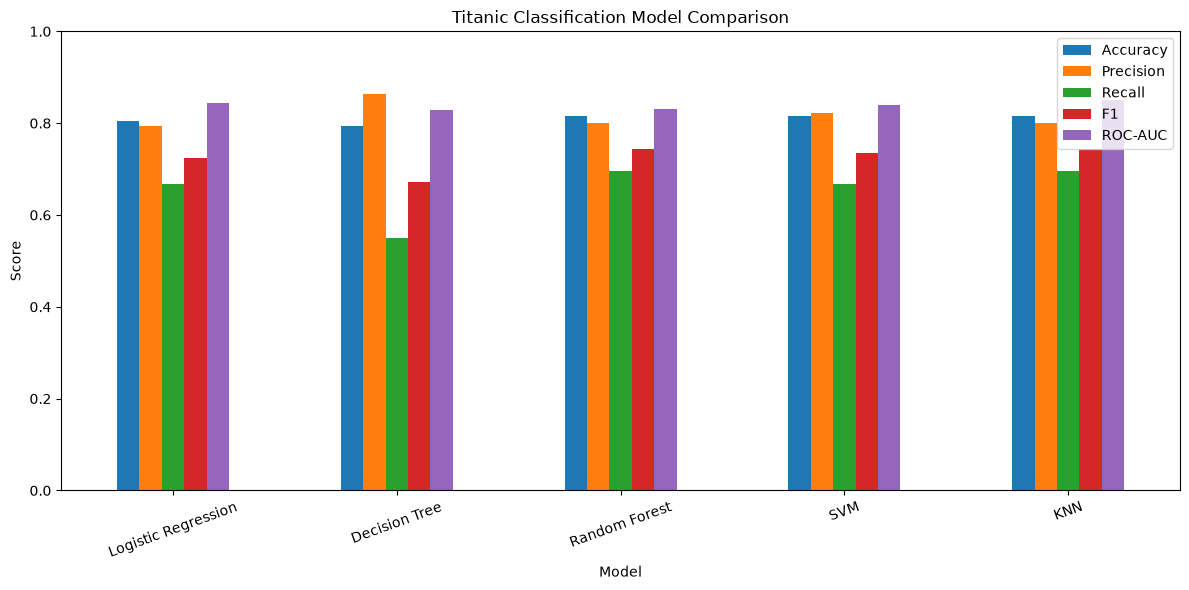

In [12]:
# Plot model comparison
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
].plot(kind="bar", figsize=(12, 6))

plt.title("Titanic Classification Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


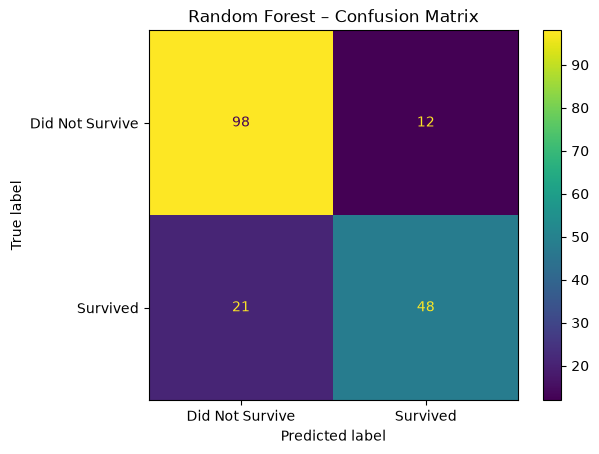

                 precision    recall  f1-score   support

Did Not Survive       0.82      0.89      0.86       110
       Survived       0.80      0.70      0.74        69

       accuracy                           0.82       179
      macro avg       0.81      0.79      0.80       179
   weighted avg       0.81      0.82      0.81       179



In [13]:
# Confusion matrix – Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)
disp.plot()
plt.title("Random Forest – Confusion Matrix")
plt.show()

print(classification_report(
    y_test, y_pred_rf,
    target_names=["Did Not Survive", "Survived"]
))


# 11. Hyperparameter Tuning – Random Forest

GridSearchCV evaluates parameter combinations using cross-validation. Here we tune the number and depth of trees and the minimum samples needed to split a node.


In [14]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 8],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline, param_grid=param_grid,
    cv=5, scoring="f1", n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("Test F1:", f1_score(y_test, y_pred_best))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_best))


Best parameters:
{'model__max_depth': 8, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV F1: 0.7469125593967958
Test Accuracy: 0.8044692737430168
Test F1: 0.7107438016528925
Test ROC-AUC: 0.8436100131752305


# 12. Quick Revision

**Logistic Regression:** probability-based, simple and interpretable baseline.

**Decision Tree:** rule-based splits; easy to explain; can overfit.

**Random Forest:** many randomized decision trees; generally reduces variance.

**SVM:** maximum-margin classifier; kernels allow non-linear boundaries; scaling is important.

**KNN:** predicts from nearby observations; scaling is important and `k` controls smoothness.

### Practice questions
1. Why is Logistic Regression used for classification?
2. What does the sigmoid function do?
3. Why can a Decision Tree overfit?
4. What does `max_depth` control?
5. How does Random Forest reduce the weaknesses of one tree?
6. What is the role of `C` in SVM?
7. Why is scaling important for SVM and KNN?
8. What does `k` mean in KNN?
9. Explain precision and recall.
10. When would F1-score be more informative than accuracy?
11. Why do we one-hot encode `sex` and `embarked`?
12. Why should preprocessing be learned from training data only?
13. What is ROC-AUC?
14. What is cross-validation?
15. What is hyperparameter tuning?
